# Implementing a concept-level reference game with EGG
In this tutorial, you will learn how to implement a concept-level reference game with EGG. The concept-level reference game was used in publications and theses. It can be modified, adapted and extended depending on the specific research question. This notebook implements the baseline implementation and the context-aware vs. context-unaware training used in [Kobrock et al. (2024)](https://aclanthology.org/2024.lrec-main.339/). Note that the settings and training presented in this tutorial are the same as in `train.py`. However, it is simplified and only works for one run. Please use the training provided in the repository to make full use of the model. For the same reasons, this tutorial notebook is accompanied by simplied versions of the `archs.py` and `dataset.py`. These simplied versions can be used for the context-aware vs. context-unaware simulations. The [`emergent-abstractions`](https://github.com/kristinakobrock/emergent-abstractions/tree/main) repository contains many more settings and game configurations to choose from.

## Installing dependencies
We used Python 3.9.15 and PyTorch 1.13.0. Generally, the minimal requirements are Python 3.6 and PyTorch 1`.1.0. requirements.txt lists the python packages needed to run this code. Additionally, please make sure you install EGG following the instructions [here](https://github.com/facebookresearch/EGG/tree/main#).

1. (optional) Create a new conda environement:
`conda create --name emergab python=3.9`
`conda activate emergab`
2. EGG can be installed as a package to be used as a library (see [here](https://github.com/facebookresearch/EGG/tree/main#) for more options):
`pip install git+https://github.com/facebookresearch/EGG.git`
3. Install packages from the requirements file:
`pip install -r requirements.txt`

In [1]:
# import Python packages
from argparse import Namespace
import torch
# print(torch.__version__)
# import torch.utils.data
import torch.nn as nn
import egg.core as core
import os
import pickle
import itertools
import yaml

# import modules from files
import dataset
from archs import Sender, Receiver
from language_analysis_local import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

opts = core.init(params=['--random_seed=7', # will initialize numpy, torch, and python RNGs
                         '--lr=1e-3',   # sets the learning rate for the selected optimizer 
                         '--batch_size=32',
                         '--optimizer=adam'])

def load_config(path: str) -> Namespace:
    """Read a yaml file and return an argparse.Namespace."""
    with open(path, 'r') as f:
        cfg_dict = yaml.safe_load(f)          # → plain dict
    return Namespace(**cfg_dict) 

# dataset split
SPLIT = (0.6, 0.2, 0.2)

cpu


## Configurations
The file `config.yml` contains the configurations for running a simulation with the concept-level reference game. You can adapt them directly in the file and load them with the following line:

In [2]:
opts = load_config('config.yml')

Additionally, the vocabulary size and message length need to be set. In the original code, we set the vocabulary size based on the number of values in a dataset and a scaling factor. Here, we assume that the vocabulary size is directly set in the `config.yml`. The maximum message lenght, i.e. the upper bound of numbers of symbols in one message is also specified by the user. If it is not specified, it is automatically set to the number of attributes + the end of sequence symbol.

In [3]:
# vocab size and message length
values = [val for val in opts.values]
attributes = [attr for attr in opts.attributes]
opts.dimensions = list(map(lambda x, y: list(itertools.repeat(y, x)), values, attributes))
vocab_size = opts.vocab_size_user
# allow user to specify a maximum message length
if opts.max_mess_len > 0:
    max_len = opts.max_mess_len
# default: number of attributes
else:
    max_len = list(map(len, opts.dimensions))

## Preparations 
Next, we set up a folder structure for saving where we can save each run according to its game specifications. This can be adopted and extended for different game settings. If the run should be saved, then first a `params.pkl` file is created that saves the configurations.

In [4]:
# set up folders for saving
if not os.path.exists('data'):
        os.makedirs('data')
if not os.path.exists('results'):
    os.makedirs('results')
    
data_set_name = '(' + str(len(opts.dimensions)) + ',' + str(opts.dimensions[0]) + ')'
data_set_names = ['(' + str(len(dimensions)) + ',' + str(dimensions[0]) + ')' for dimensions in opts.dimensions ]
folder_names = [os.path.join("results", (dataset_name + '_game_size_' + str(opts.game_size))) for dataset_name in data_set_names]
#folder_name = os.path.join("results", folder_name)

opts.game_setting = 'context_aware'

# create subfolders if necessary / mod games are intended to be used for testing misunderstanding conditions

opts.game_path = [[], []]
for folder_name in folder_names:
    opts.game_path[0].append(os.path.join(opts.path, folder_name, "original", opts.game_setting))
    opts.game_path[1].append(os.path.join(opts.path, folder_name, "mod", opts.game_setting))
    if not os.path.exists(opts.game_path[0][-1]):
        os.makedirs(opts.game_path[0][-1])
    if not os.path.exists(opts.game_path[1][-1]):
        os.makedirs(opts.game_path[1][-1])

# saving
if opts.save:
    # make folder for new run
    latest_runs = [[], []]
    latest_runs[0] = [len(x) for x in list(map(os.listdir ,opts.game_path[0]))]
    latest_runs[1] = [len(x) for x in list(map(os.listdir ,opts.game_path[1]))] # was -1, make -0 for 1st run, +1 for every next one
    opts.save_paths = [[], []]
    for game_path, run_len in zip(opts.game_path[0], latest_runs[0]):
        opts.save_paths[0].append(os.path.join(game_path, str(run_len)))
        if not os.path.exists(opts.save_paths[0][-1]):
            os.makedirs(opts.save_paths[0][-1])
        pickle.dump(opts, open(opts.save_paths[0][-1] + '/params.pkl', 'wb'))
        save_epoch = opts.n_epochs
    for game_path, run_len in zip(opts.game_path[1], latest_runs[1]):
        opts.save_paths[1].append(os.path.join(game_path, str(run_len)))
        if not os.path.exists(opts.save_paths[1][-1]):
            os.makedirs(opts.save_paths[1][-1])
        pickle.dump(opts, open(opts.save_paths[1][-1] + '/params.pkl', 'wb'))
        save_epoch = opts.n_epochs
else:
    save_epoch = None

## Dataset
The dataset is a symbolic dataset that is created in the dataset module. The dimensions are given by the numbers of attributes and values each object in the dataset has. The dataset can be used for simulating a concept-level reference game or a single object reference game. The latter can be achieved by setting `opts.game_size=1`. Here, we use `opts.game_size=10`, i.e. in each round of the game, speakers and listeners need to communicate about 10 objects that together form a target concept which needs to be discriminated from 10 distractors. There is also an option to load a pre-created dataset to save time if multiple runs with the same configuration need to be trained. The dataset is implemented based on the torch DataSet class, so it can be loaded with the PyTorch DataLoader.

In [5]:
# Dataset
# generate if not given

if not opts.load_dataset:
    data_sets = []
    for dimension in opts.dimensions:
        data_sets.append(dataset.DataSet(dimension,
                                   game_size=opts.game_size,
                                   scaling_factor=opts.scaling_factor,
                                   device=device))
        if opts.save_datasets:
            path = ('data/dim(' + str(len(dimension)) + ',' + str(dimension[0]) + ')' + str(opts.game_size) + '_sf' +
            str(opts.scaling_factor) + '.ds')
            with open(path, "wb") as f:
                torch.save(data_set, f)
                print("Data set is saved as: " + path)
else:
    data_sets = []
    for path in os.scandir(opts.load_dataset):
        data_sets.append(torch.load(path, weights_only=False)) # added , weights_only=False to fix UnpicklingError)
    #data_set = torch.load(opts.path + 'data/' + opts.load_dataset, weights_only=False) # added , weights_only=False to fix UnpicklingError 
        print('data loaded from: ' + str(path))

        
train = list(itertools.repeat(None, len(data_sets)))
val = list(itertools.repeat(None, len(data_sets)))
test = list(itertools.repeat(None, len(data_sets)))

for data_set, i in zip(data_sets, range(len(data_sets))):
    train[i], val[i], test[i] = data_set

dimensions = [t.dimensions for t in train]
print(test)
train = [torch.utils.data.DataLoader(t, batch_size=opts.batch_size, shuffle=True) for t in train]
val = [torch.utils.data.DataLoader(v, batch_size=opts.batch_size, shuffle=False, drop_last=True) for v in val]
test = [torch.utils.data.DataLoader(tst, batch_size=opts.batch_size, shuffle=False) for tst in test]

data loaded from: <DirEntry 'dim(3,4)10_sf10.ds'>
data loaded from: <DirEntry 'dim(3,8)10_sf10.ds'>
data loaded from: <DirEntry 'dim(4,3)10_sf10.ds'>


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



## Game
For the game, we need the training objective, or loss, the sender and receiver (speaker and listener) and we initialize a game class from EGG. Here, we use `core.RnnSenderGS`, `core.RnnReceiverGS` and the `core.SenderReceiverRnnGS` wrapper which is used to train RNN agents with the Gumbel-softmax relaxation. The RnnGS wrappers allow for messages consisting of multiple symbols. EGG offers more wrappers for other game configurations, e.g. using single-symbol messages or training with REINFORCE. Check out the EGG documentation!

In [6]:
def loss(_sender_input, _message, _receiver_input, receiver_output, labels, _aux_input):
    """
    Loss needs to be defined for gumbel softmax relaxation.
    For a discriminative game, accuracy is computed by comparing the index with highest score in Receiver
    output (a distribution of unnormalized probabilities over target positions) and the corresponding 
    label read from input, indicating the ground-truth position of the target.
    Adaptation to concept game with multiple targets after Mu & Goodman (2021) with BCEWithLogitsLoss
        receiver_output: Tensor of shape [batch_size, n_objects]
        labels: Tensor of shape [batch_size, n_objects]
    """
    loss_fn = nn.BCEWithLogitsLoss()
    loss = loss_fn(receiver_output, labels)
    receiver_pred = (receiver_output > 0).float()
    per_game_acc = (receiver_pred == labels).float().mean(1).cpu().numpy()  # all labels have to be predicted correctly
    acc = per_game_acc.mean()
    return loss, {'acc': acc}

In [7]:
# Game
# initialize sender and receiver agents
senders = [[Sender(opts.hidden_size, sum(dim), opts.game_size, True) for dim in dimensions],
           [{ 'send1': Sender(opts.hidden_size, sum(dim), opts.game_size, True),
              'send2': Sender(opts.hidden_size, sum(dim), opts.game_size, True) } for dim in dimensions]]
recivers = [[Receiver(sum(dim), opts.hidden_size) for dim in dimensions],
           [{ 'reciv1': Receiver(sum(dim), opts.hidden_size),
              'reciv2': Receiver(sum(dim), opts.hidden_size) } for dim in dimensions]]

# initialize game
for i in range(len(senders[0])):
    senders[0][i] = core.RnnSenderGS(senders[0][i],
                          vocab_size,
                          int(opts.hidden_size / 2),
                          opts.hidden_size,
                          cell=opts.sender_cell,
                          max_len=max_len[i],
                          temperature=opts.temperature)
for i in range(len(senders[0])):
    senders[1][i]['send1'] = core.RnnSenderGS(senders[1][i]['send1'],
                          vocab_size,
                          int(opts.hidden_size / 2),
                          opts.hidden_size,
                          cell=opts.sender_cell,
                          max_len=max_len[i],
                          temperature=opts.temperature)
    senders[1][i]['send2'] = core.RnnSenderGS(senders[1][i]['send2'],
                          vocab_size,
                          int(opts.hidden_size / 2),
                          opts.hidden_size,
                          cell=opts.sender_cell,
                          max_len=max_len[i],
                          temperature=opts.temperature)
for i in range(len(recivers[0])):
    recivers[0][i] = core.RnnReceiverGS(recivers[0][i],
                              vocab_size,
                              int(opts.hidden_size / 2),
                              opts.hidden_size,
                              cell=opts.receiver_cell)

for i in range(len(recivers[0])):
    recivers[1][i]['reciv1'] = core.RnnReceiverGS(recivers[1][i]['reciv1'],
                              vocab_size,
                              int(opts.hidden_size / 2),
                              opts.hidden_size,
                              cell=opts.receiver_cell)
    recivers[1][i]['reciv2'] = core.RnnReceiverGS(recivers[1][i]['reciv2'],
                              vocab_size,
                              int(opts.hidden_size / 2),
                              opts.hidden_size,
                              cell=opts.receiver_cell)

games = [] # obj structure: game[[game1_original, game1_mod_firstbatch, game1_mod_secondbatch], [game2...], ...]
for i in range(len(senders[0])):
    game_obj = []
    game_obj.append(core.SenderReceiverRnnGS(senders[0][i], recivers[0][i], loss, length_cost=opts.length_cost))
    game_obj.append(core.SenderReceiverRnnGS(senders[1][i]['send1'], recivers[1][i]['reciv1'], loss, length_cost=opts.length_cost))
    game_obj.append(core.SenderReceiverRnnGS(senders[1][i]['send2'], recivers[1][i]['reciv2'], loss, length_cost=opts.length_cost))
    games.append(game_obj)

You can look at the game, sender and receiver configurations by printing them here, e.g.:

## Training
For training, we use the Adam optimizer and the learning rate specified in the `config.yml`. We specify callbacks for saving and printing to console and initialize the EGG `core.Trainer`. If the same configuration was trained and saved already, the model can be loaded from checkpoint. Else, the model is trained.

In [8]:
# Training
# set optimizer
optimizers = [[torch.optim.Adam([
    {'params': game[0].sender.parameters(), 'lr': opts.learning_rate},
    {'params': game[0].receiver.parameters(), 'lr': opts.learning_rate}
]), 
torch.optim.Adam([
    {'params': game[1].sender.parameters(), 'lr': opts.learning_rate},
    {'params': game[1].receiver.parameters(), 'lr': opts.learning_rate}
]),torch.optim.Adam([
    {'params': game[2].sender.parameters(), 'lr': opts.learning_rate},
    {'params': game[2].receiver.parameters(), 'lr': opts.learning_rate}
])] for game in games] 


# setup training and callbacks
# results/ data set name/ kind_of_dataset/ run/
callbacks = [[], []]
for i in range(len(games)):
    callbacks[0].append([SavingConsoleLogger(print_train_loss=True, as_json=True,
                                 save_path=opts.save_paths[0][i], save_epoch=save_epoch),
             core.TemperatureUpdater(agent=senders[0][i], decay=opts.temp_update, minimum=0.5)])
    callbacks[1].append([SavingConsoleLogger(print_train_loss=True, as_json=True,
                                 save_path=opts.save_paths[1][i], save_epoch=save_epoch),
             core.TemperatureUpdater(agent=senders[1][i]['send1'], decay=opts.temp_update, minimum=0.5)])
    if opts.save:
        callbacks[0][-1].extend([core.callbacks.InteractionSaver([opts.n_epochs],
                                                          test_epochs=[opts.n_epochs],
                                                          checkpoint_dir=opts.save_paths[0][i]),
                          core.callbacks.CheckpointSaver(opts.save_paths[0][i], checkpoint_freq=0)])
        callbacks[1][-1].extend([core.callbacks.InteractionSaver([opts.n_epochs],
                                                          test_epochs=[opts.n_epochs],
                                                          checkpoint_dir=opts.save_paths[1][i]),
                          core.callbacks.CheckpointSaver(opts.save_paths[1][i], checkpoint_freq=0)])
        
trainers = [] # same structure as games list obj
for i in range(len(games)):
    trainer_obj = []
    trainer_obj.append(core.Trainer(game=games[i][0], optimizer=optimizers[i][0],
                       train_data=train[i], validation_data=val[i], callbacks=callbacks[0][i], device=device))
    trainer_obj.append(core.Trainer(game=games[i][1], optimizer=optimizers[i][1],
                       train_data=train[i], validation_data=val[i], callbacks=callbacks[1][i], device=device))
    trainer_obj.append(core.Trainer(game=games[i][2], optimizer=optimizers[i][2],
                       train_data=train[i], validation_data=val[i], callbacks=callbacks[1][i], device=device))
    trainers.append(trainer_obj)

# if checkpoint path is given, load checkpoint and skip training
if opts.load_checkpoint:
    trainer.load_from_checkpoint(opts.checkpoint_path, map_location=device)
    for trainer_obj in trainers:
        trainer_obj[0].load_from_checkpoint(opts.checkpoint_path, map_location=device)
        trainer_obj[1].load_from_checkpoint(opts.checkpoint_path, map_location=device)
        trainer_obj[2].load_from_checkpoint(opts.checkpoint_path, map_location=device)
        aux_reciver = trainer_obj[1].game.receiver
        trainer_obj[1].game.receiver = trainer_obj[2].game.receiver
        trainer_obj[2].game.receiver = aux_reciver
        trainer_obj[1].train(n_epochs=opts.n_epochs)
else:
    for trainer_obj in trainers:
        trainer_obj[0].train(n_epochs=opts.n_epochs)
        trainer_obj[1].train(n_epochs=opts.n_epochs)
        trainer_obj[2].train(n_epochs=opts.n_epochs)
        aux_reciver = trainer_obj[1].game.receiver
        trainer_obj[1].game.receiver = trainer_obj[2].game.receiver
        trainer_obj[2].game.receiver = aux_reciver
        trainer_obj[1].train(n_epochs=opts.n_epochs)
        
    

{"loss": 0.487114816904068, "acc": 0.7481416463851929, "length": 4.7294416427612305, "mode": "train", "epoch": 1}
{"loss": 0.38753414154052734, "acc": 0.8349740505218506, "length": 5.0, "mode": "test", "epoch": 1}
{"loss": 0.29321548342704773, "acc": 0.8807052373886108, "length": 4.999372482299805, "mode": "train", "epoch": 2}
{"loss": 0.34730470180511475, "acc": 0.8478647470474243, "length": 5.0, "mode": "test", "epoch": 2}
{"loss": 0.2385580986738205, "acc": 0.909484326839447, "length": 4.999813079833984, "mode": "train", "epoch": 3}
{"loss": 0.31896641850471497, "acc": 0.8591145873069763, "length": 5.0, "mode": "test", "epoch": 3}
{"loss": 0.20473352074623108, "acc": 0.9283550381660461, "length": 4.9999098777771, "mode": "train", "epoch": 4}
{"loss": 0.3056078255176544, "acc": 0.8732941746711731, "length": 5.0, "mode": "test", "epoch": 4}
{"loss": 0.17710061371326447, "acc": 0.942674994468689, "length": 4.9999566078186035, "mode": "train", "epoch": 5}
{"loss": 0.2541307508945465, "a

The `SavingConsoleLogger` callback is defined in `language_analysis_local`. It prints the loss, accuracy and effective message length for each epoch in training and validation (here called "test") mode. After training, the performance is evaluated once on the test dataset:

In [9]:
# after training evaluate performance on the test data set
if len(test):
    for i in range(len(trainers)):
        trainers[i][0].validation_data = test[i]
        eval_loss, interaction = trainers[i][0].eval()
        acc = torch.mean(interaction.aux['acc']).item()
        print("test accuracy: " + str(acc))
        if opts.save:
            loss_and_metrics_path = os.path.join(opts.save_paths[0][i], 'loss_and_metrics.pkl')
            if os.path.exists(loss_and_metrics_path):
                with open(loss_and_metrics_path, 'rb') as pickle_file:
                    loss_and_metrics = pickle.load(pickle_file)
            else:
                loss_and_metrics = {}
    
            loss_and_metrics['final_test_loss'] = eval_loss
            loss_and_metrics['final_test_acc'] = acc
            pickle.dump(loss_and_metrics, open(opts.save_paths[0][i] + '/loss_and_metrics.pkl', 'wb'))
        
        trainers[i][1].validation_data = test[i]
        eval_loss, interaction = trainers[i][1].eval()
        acc = torch.mean(interaction.aux['acc']).item()
        print("test accuracy: " + str(acc))
        if opts.save:
            loss_and_metrics_path = os.path.join(opts.save_paths[1][i], 'loss_and_metrics.pkl')
            if os.path.exists(loss_and_metrics_path):
                with open(loss_and_metrics_path, 'rb') as pickle_file:
                    loss_and_metrics = pickle.load(pickle_file)
            else:
                loss_and_metrics = {}
    
            loss_and_metrics['final_test_loss'] = eval_loss
            loss_and_metrics['final_test_acc'] = acc
            pickle.dump(loss_and_metrics, open(opts.save_paths[1][i] + '/loss_and_metrics.pkl', 'wb'))

test accuracy: 0.9061431884765625
test accuracy: 0.868228554725647
test accuracy: 0.8876507878303528
test accuracy: 0.7977763414382935
test accuracy: 0.9074119925498962
test accuracy: 0.7994975447654724


# Results and analysis
If you have saved the results, then a folder which specifies the most important game configurations is created in the results folder. The results for each run consist of the following parts:
- `params.pkl`: File which saves the run configurations
- `loss_and_metrics.pkl`: File which saves the loss, accuracy, and message length metrics similar to the console output during training
- `final.tar`: The trained model which can be loaded with opts.load_checkpoint
- The `interactions` folder which consists of train and validation interactions (optionally also test interactions). By default, the interactions of the final epoch are saved. We'll see how to analyze the interactions below.

## Model performance
Now, we can turn to the analysis. The first step is always to look at the model performance to see whether the model was trained and achieved a satisfying performance.

In [10]:
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('default')
import random
import seaborn

from utils.load_results import *
from utils.plot_helpers import *
from utils.analysis_from_interaction import *

In [11]:
# paths = folder_names # 'results/(3,4)_game_size_10'
#paths = [['results\\(4,3)_game_size_10\\original', 'results\\(3,4)_game_size_10\\original', 'results\\(3,8)_game_size_10\\original'], ['results\\(4,3)_game_size_10\\mod', 'results\\(3,4)_game_size_10\\mod', 'results\\(3,8)_game_size_10\\mod']]
#print(opts.save_paths)
paths = [[p.split("\\context")[0] for p in opts.save_paths[0]], [p.split("\\context")[0] for p in opts.save_paths[1]]]

[[[0.74814165 0.88070524 0.90948433 0.92835504 0.94267499 0.95104665
   0.95741266 0.96087587 0.96388185 0.96576655 0.96780646 0.96809542
   0.9689967  0.96901405 0.96986371]
  [0.74814165 0.88070524 0.90948433 0.92835504 0.94267499 0.95104665
   0.95741266 0.96087587 0.96388185 0.96576655 0.96780646 0.96809542
   0.9689967  0.96901405 0.96986371]
  [0.74814165 0.88070524 0.90948433 0.92835504 0.94267499 0.95104665
   0.95741266 0.96087587 0.96388185 0.96576655 0.96780646 0.96809542
   0.9689967  0.96901405 0.96986371]
  [0.74814165 0.88070524 0.90948433 0.92835504 0.94267499 0.95104665
   0.95741266 0.96087587 0.96388185 0.96576655 0.96780646 0.96809542
   0.9689967  0.96901405 0.96986371]
  [0.74814165 0.88070524 0.90948433 0.92835504 0.94267499 0.95104665
   0.95741266 0.96087587 0.96388185 0.96576655 0.96780646 0.96809542
   0.9689967  0.96901405 0.96986371]]]
[[[0.74927884 0.86781871 0.88990003 0.90458226 0.91677916 0.92555577
   0.93208522 0.9372862  0.94130558 0.94538546 0.94752

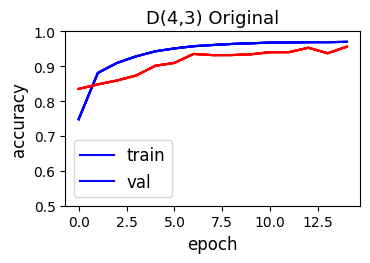

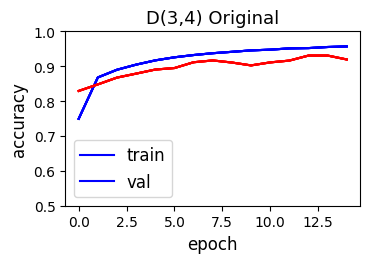

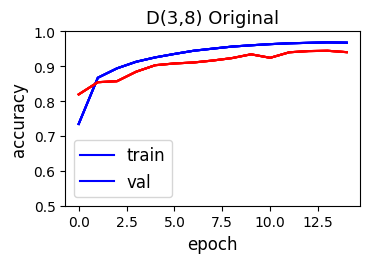

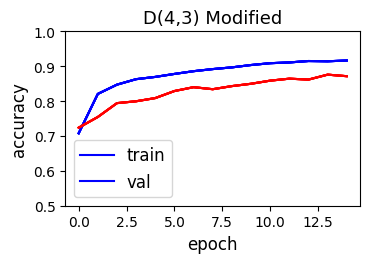

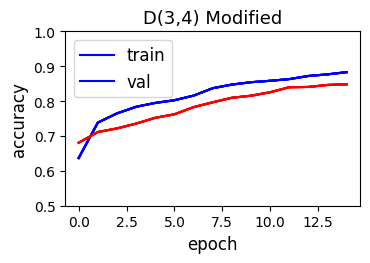

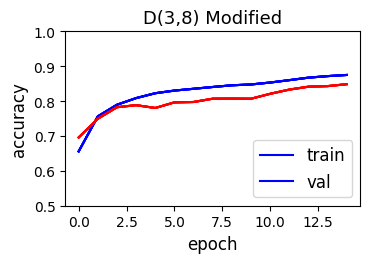

In [13]:
all_accuracies_total = [[], []]
plotting_names = [[],[]]
accuracies_means = [{
    'train (4,3)': .0,
    'train (3,4)': .0,
    'train (3,8)': .0,
    'val (4,3)': .0,
    'val (3,4)': .0,
    'val (3,8)': .0
}, {
    'train (4,3)': .0,
    'train (3,4)': .0,
    'train (3,8)': .0,
    'val (4,3)': .0,
    'val (3,4)': .0,
    'val (3,8)': .0
}]
for path, i in zip(paths, range(len(paths))):
    for p in path:
        if i == 0:
            mod = 'Original'
        else:
            mod = 'Modified'
        all_accuracies, file_name = load_accuracies([p], n_runs=5, n_epochs=opts.n_epochs, val_steps=1, context_unaware=False)
        plotting_name = ('D' + p.split("_game_size")[0].split("\\")[1] + ' ' + mod)
        plotting_names[i].append(plotting_name)
        plot_training_trajectory(all_accuracies['train_acc'], all_accuracies['val_acc'], ylim=(0.5, 1), steps=(1, 1), n_epochs=opts.n_epochs, plot_indices=(1,), titles= [plotting_name])
        all_accuracies_total[i].append(all_accuracies)
        
        # taking the mean of all runs
        train_mean = np.mean(all_accuracies["train_acc"], axis=1)[:, np.newaxis, :]  # shape (num_datasets, 1, num_epochs)
        val_mean   = np.mean(all_accuracies["val_acc"], axis=1)[:, np.newaxis, :]    # shape (num_datasets, 1, num_epochs)
        accuracies_means[i]['train ' + p.split("_game_size")[0].split("\\")[1]] = train_mean
        accuracies_means[i]['val ' + p.split("_game_size")[0].split("\\")[1]] = val_mean

In [14]:
# Initial accuracies
initial_train_acc = {
    "D(4,3) Original": accuracies_means[0]['train (4,3)'][0][0][0],
    "D(3,4) Original": accuracies_means[0]['train (3,4)'][0][0][0],
    "D(3,8) Original": accuracies_means[0]['train (3,8)'][0][0][0],
    "D(4,3) Modified": accuracies_means[1]['train (4,3)'][0][0][0],
    "D(3,4) Modified": accuracies_means[1]['train (3,4)'][0][0][0],
    "D(3,8) Modified": accuracies_means[1]['train (3,8)'][0][0][0],
}

initial_val_acc = {
    "D(4,3) Original": accuracies_means[0]['val (4,3)'][0][0][0],
    "D(3,4) Original": accuracies_means[0]['val (3,4)'][0][0][0],
    "D(3,8) Original": accuracies_means[0]['val (3,8)'][0][0][0],
    "D(4,3) Modified": accuracies_means[1]['val (4,3)'][0][0][0],
    "D(3,4) Modified": accuracies_means[1]['val (3,4)'][0][0][0],
    "D(3,8) Modified": accuracies_means[1]['val (3,8)'][0][0][0],
}

# Printing initial accuracies
print(f"{'Condition':<25} | {'Initial Train Accuracy':>18}")
print("-" * 48)

for k, v in initial_train_acc.items():
    print(f"{k:<25} | {v:>18.4f}")

print(f"{'Condition':<25} | {'Initial Val Accuracy':>18}")
print("-" * 48)

for k, v in initial_val_acc.items():
    print(f"{k:<25} | {v:>18.4f}")

# Final accuracies
final_train_acc = {
    "D(4,3) Original": accuracies_means[0]['train (4,3)'][0][0][-1],
    "D(3,4) Original": accuracies_means[0]['train (3,4)'][0][0][-1],
    "D(3,8) Original": accuracies_means[0]['train (3,8)'][0][0][-1],
    "D(4,3) Modified": accuracies_means[1]['train (4,3)'][0][0][-1],
    "D(3,4) Modified": accuracies_means[1]['train (3,4)'][0][0][-1],
    "D(3,8) Modified": accuracies_means[1]['train (3,8)'][0][0][-1],
}

final_val_acc = {
    "D(4,3) Original": accuracies_means[0]['val (4,3)'][0][0][-1],
    "D(3,4) Original": accuracies_means[0]['val (3,4)'][0][0][-1],
    "D(3,8) Original": accuracies_means[0]['val (3,8)'][0][0][-1],
    "D(4,3) Modified": accuracies_means[1]['val (4,3)'][0][0][-1],
    "D(3,4) Modified": accuracies_means[1]['val (3,4)'][0][0][-1],
    "D(3,8) Modified": accuracies_means[1]['val (3,8)'][0][0][-1],
}

# Printing final accuracies
print(f"{'Condition':<25} | {'Final Train Accuracy':>18}")
print("-" * 48)

for k, v in final_train_acc.items():
    print(f"{k:<25} | {v:>18.4f}")

print(f"{'Condition':<25} | {'Final Val Accuracy':>18}")
print("-" * 48)

for k, v in final_val_acc.items():
    print(f"{k:<25} | {v:>18.4f}")

Condition                 | Initial Train Accuracy
------------------------------------------------
D(4,3) Original           |             0.7481
D(3,4) Original           |             0.7493
D(3,8) Original           |             0.7345
D(4,3) Modified           |             0.7077
D(3,4) Modified           |             0.6368
D(3,8) Modified           |             0.6558
Condition                 | Initial Val Accuracy
------------------------------------------------
D(4,3) Original           |             0.8350
D(3,4) Original           |             0.8291
D(3,8) Original           |             0.8192
D(4,3) Modified           |             0.7238
D(3,4) Modified           |             0.6805
D(3,8) Modified           |             0.6957
Condition                 | Final Train Accuracy
------------------------------------------------
D(4,3) Original           |             0.9699
D(3,4) Original           |             0.9568
D(3,8) Original           |             0.9675

We can also plot how the message length varies during training.

In [ ]:
for types_of_acc, i in zip(all_accuracies_total, range(len(all_accuracies_total))):
    for all_accuracies, j in zip(types_of_acc, range(len(types_of_acc))):        
        title_string = [plotting_names[i][j]]
        print(title_string)
        plot_training_trajectory(all_accuracies['train_acc'], all_accuracies['val_acc'], message_length_train=all_accuracies['train_message_lengths'], message_length_val=all_accuracies['val_message_lengths'], steps=(1, 1), n_epochs=opts.n_epochs, plot_indices=(1,), message_length_plot=True, train_only=True, titles=title_string)

## Interactions
Next, let's look at the saved interactions. Using the interactions, we can do a qualitative analysis of the messages produced for the concepts in the dataset or use them to compute quantitative metrics.
An interaction consists of the following parts:
- sender_input: The input to the sender, i.e. objects in the dataset (one-hot encoded)
- receiver_input: Same for the receiver input
- labels: These are the true labels that the receiver output needs to be compared to
- aux_input: Optional auxiliary input (here empty)
- message: The message that was sent by the sender (as logits)
- receiver_output: The receiver predictions (labels for the objects)
- message_length: The length of the messages sent by the sender
- aux: An optional dictionary, here we save the console output (accuracy, loss, length)

### Qualitative analysis
In the emergent-abstractions repository, `analyis_qualitative.ipynb` provides examples for a qualitative analysis. Here are examples for how to reconstruct the input and message from the saved interactions.

In [ ]:
#if opts.save:
    # only works if opts.save = True
#    paths = opts.save_paths
#else:
paths =  [['results\\(4,3)_game_size_10\\original/context_aware/', 'results\\(3,4)_game_size_10\\original/context_aware/', 'results\\(3,8)_game_size_10\\original/context_aware/'], ['results\\(4,3)_game_size_10\\mod/context_aware/', 'results\\(3,4)_game_size_10\\mod/context_aware/', 'results\\(3,8)_game_size_10\\mod/context_aware/']]
    #'results/(3,4)_game_size_10/context_aware/0'

In [ ]:
all_interactions = []
for n in range(5):
    paths_to_interaction_train_original = [(path + str(n) + '/interactions/train/epoch_' + str(opts.n_epochs) + '/interaction_gpu0') for path in paths[0]] 
    paths_to_interaction_train_mod =  [(path + str(n) + '/interactions/train/epoch_' + str(opts.n_epochs) + '/interaction_gpu0') for path in paths[1]]
    interactions = [[torch.load(p_, weights_only=False) for p_ in paths_to_interaction_train_original], [torch.load(p_, weights_only=False) for p_ in paths_to_interaction_train_mod]]
    all_interactions.append(interactions)

To look at the messages, we need to argmax the logits:

In [ ]:
all_messages = []
for intractions in all_interactions:
    messages = [[interaction.message.argmax(dim=-1) for interaction in intractions[0]], [interaction.message.argmax(dim=-1) for interaction in intractions[1]]]
    messages[0] = [msg.tolist() for msg in messages[0]]
    messages[1] =   [msg.tolist() for msg in messages[1]]
    all_messages.append(messages)

messages_dict = {'initial interaction': {
                     'original': {'(4,3)': all_messages[0][0][0][0], '(3,4)': all_messages[0][0][1][0], '(3,8)': all_messages[0][0][2][0]},
                    'modified': {'(4,3)': all_messages[0][1][0][0], '(3,4)': all_messages[0][1][1][0], '(3,8)': all_messages[0][1][2][0]}},
                 'last interaction': {
                     'original': {'(4,3)': all_messages[-1][0][0][0], '(3,4)': all_messages[-1][0][1][0], '(3,8)': all_messages[-1][0][2][0]},
                    'modified': {'(4,3)': all_messages[-1][1][0][0], '(3,4)': all_messages[-1][1][1][0], '(3,8)': all_messages[-1][1][2][0]}}
                }

# Define the order of tuples (as they appear in your original display)
tuple_order = ['(4,3)', '(3,4)', '(3,8)']

# Build separate DataFrames for initial and last interactions
df_initial = pd.DataFrame({
    'Original': [messages_dict['initial interaction']['original'][tup] for tup in tuple_order],
    'Modified': [messages_dict['initial interaction']['modified'][tup] for tup in tuple_order]
}, index=tuple_order)

df_last = pd.DataFrame({
    'Original': [messages_dict['last interaction']['original'][tup] for tup in tuple_order],
    'Modified': [messages_dict['last interaction']['modified'][tup] for tup in tuple_order]
}, index=tuple_order)


df_combined = pd.concat(
    {'initial': df_initial, 'last': df_last},
    names=['interaction', 'tuple']
)

df_combined

To look at the concepts, we need to de-one-hot and make sense of the symbolic datasets:

In [ ]:
concepts_df = {'dataset': [], 'run': [], 'interaction': [], 'concept_idx': [],
               'n_objects': [], 'n_fixed_attrs': []}
all_fixed = []
all_objects = []
for n in range(5):
    sender_inputs_original = [interaction.sender_input for interaction in all_interactions[n][0]]
    sender_inputs_mod = [interaction.sender_input for interaction in all_interactions[n][1]]
    sender_inputs = [sender_inputs_original, sender_inputs_mod]
    n_targets = [[int(s_i.shape[1]/2) for s_i in sender_inputs[0]], [int(s_i.shape[1]/2) for s_i in sender_inputs[1]]]
    target_objects = [[], []]
    for sender_input_list, n_target_list, i in zip(sender_inputs, n_targets, range(len(sender_inputs))):
        for sender_input, n_target, value, j in zip(sender_input_list, n_target_list, opts.values, range(len(sender_input_list))):
            target_objects[i].append(k_hot_to_attributes(sender_input[:, :n_target], dimsize=value))
            # concepts are defined by a list of target objects (here one sampled target object) and a fixed vector
            (objects, fixed) = retrieve_concepts_sampling(target_objects[i][-1], all_targets=True)
            concepts = list(zip(objects, fixed))
            all_fixed.append(fixed)
            all_objects.append(objects)
            for c_idx, (objcs, fixd) in enumerate(concepts):
                concepts_df['dataset'].append(plotting_names[i][j])
                concepts_df['run'].append(n)
                concepts_df['interaction'].append(0)  # one interaction object contains all games
                concepts_df['concept_idx'].append(c_idx)
                concepts_df['n_objects'].append(len(objcs))
                concepts_df['n_fixed_attrs'].append(int(sum(fixd)))

In [ ]:
###### testng

# Convert to DataFrame
concepts_df = pd.DataFrame(concepts_df)


#concepts_df['type'] = concepts_df['dataset'].apply(lambda x: 'Mod' if 'Mod' in x else 'Original')

# Summary: average abstraction per dataset
summary = concepts_df.groupby('dataset')['n_fixed_attrs'].mean().reset_index()

summary


### Quantitative analysis
In the emergent-abstractions repository, the notebook `evaluate_metrics.ipynb` is used to compute metrics based on the interactions which are then summarized and plotted in `analysis.ipynb`. Here is an example for how to compute the Normalized Mutual Information score, i.e. one-to-one mappings between messages and concepts on the trained lexicon.

#### Information-theoretic scores

In [ ]:
# this is computed in `evaluate_metrics.iypnb`
for path_type in opts.save_paths:
    for path, value in zip(path_type, opts.values):
        path = path.split("context_aware\\")[0] + "context_aware\\"
        for run_n in range(5):
            path_to_interaction = (path + str(run_n) + '/interactions/train/epoch_' + str(opts.n_epochs) + '/interaction_gpu0')
            interaction = torch.load(path_to_interaction, weights_only=False)
            attributes = int(path.split(",")[1].split(")")[0])
            scores = information_scores(interaction, attributes, value, normalizer="arithmetic", is_gumbel=True, trim_eos=True, max_mess_len=21)   
            pickle.dump(scores, open(path + str(run_n) + '/entropy_scores.pkl', 'wb'))

In [ ]:
# this is implemented in `analysis.ipynb`
entropy_scores = [[], []]
entropies = [[], []]
for folder_names, i in zip(opts.save_paths, range(len(opts.save_paths))):
    for name in folder_names:
        entropi = load_entropies([name.split("\\context")[0]], context_unaware=False, verbose=False)
        dataset_name = name.split("results\\")[1].split("_game_size")[0] + ' ' + name.split("\context")[0].split("_10\\")[1]
        entropy_scores[i].append(entropi)
        entropies[i].append([entropy_scores[i][-1]['NMI'], entropy_scores[i][-1]['effectiveness'], entropy_scores[i][-1]['consistency'], dataset_name])

Usually, scores are computed over multiple runs (e.g. 5) and we report means and standard deviations over five runs to account for differences due to initialization etc.

In [ ]:
entropy_dicts = [[], []]
for elem in entropies[0]:
    entropy_dicts[0].append({'NMI': (np.round(np.nanmean(elem[0], axis=-1), 3), np.std(elem[0], axis=-1)), 
                            'effectiveness': (np.round(np.nanmean(elem[1], axis=-1), 3),  np.std(elem[1], axis=-1)), 
                             'consistency': (np.round(np.nanmean(elem[2], axis=-1), 3),  np.std(elem[2], axis=-1)), 'data set': elem[3]})
for elem in entropies[1]:
    entropy_dicts[1].append({'NMI': (np.round(np.nanmean(elem[0], axis=-1), 3), np.std(elem[0], axis=-1)), 
                            'effectiveness': (np.round(np.nanmean(elem[1], axis=-1), 3),  np.std(elem[1], axis=-1)), 
                             'consistency': (np.round(np.nanmean(elem[2], axis=-1), 3),  np.std(elem[2], axis=-1)), 'data set': elem[3]})


entropy_dicts

In [ ]:
metrics = {'Size': [], 'Type': [], 'Metric': [], 'Value (mean, sd)': []}
for entropy_dict in entropy_dicts:
    for elem in entropy_dict:
        data_set_name = elem['data set'].split(" ")
        for key in elem:
            if key != 'data set':
                metrics['Size'].append(data_set_name[0])
                metrics['Type'].append(data_set_name[1])
                metrics['Metric'].append(key)
                metrics['Value (mean, sd)'].append(elem[key])

# Convert to DataFrame
metrics_df = pd.DataFrame(metrics)
metrics_df[['mean', 'sd']] = pd.DataFrame(
    metrics_df['Value (mean, sd)'].tolist(),
    index=metrics_df.index
)

mean_per_metric = (
    metrics_df
    .groupby(['Size', 'Type', 'Metric'], as_index=False)
    .agg(
        mean_value=('mean', 'mean'),
    )
)

mean_per_metric

The NMI is 0.6 which means that there is quite some ambiguity in the mapping between concepts and messages. The effectiveness score is computed based on the conditional entropy $H(C|M)$ and quantifies how much uncertainty remains about the concepts after knowing the messages, or, in other words, how effectively a message picks out a target concept. The consistency score is computed based on the conditional entropy $H(M|C)$ and quantifies how much uncertainty remains about the messages after knowing the concepts, or, in other words, how consistently a message is used to communicate a target concept.
<img src="Info_scores.jpeg" width="400"/>

#### Message length
We can also check whether message lengths differ for the different concepts that need to be communicated, e.g. based on how many attributes need to be communicated in a target concept.

In [ ]:
# this is computed in `evaluate_metrics.iypnb`
for path_type in paths:
    for path in path_type:
        for run in range(5):
            path_to_interaction = (path + str(run) + '/interactions/train/epoch_' + str(opts.n_epochs) + '/interaction_gpu0')
            interaction = torch.load(path_to_interaction, weights_only=False)
            attributes = int(path.split(",")[1].split(")")[0])
            ml, ml_concept = message_length_per_hierarchy_level(interaction, attributes)
            
            pickle.dump(ml, open(path + str(run)  + '/message_length.pkl', 'wb'))
            pickle.dump(ml_concept, open(path + str(run)   + '/message_length_hierarchical.pkl', 'wb'))

In [ ]:
# this is implemented in `analyis.ipynb`
ml_dict = {'dataset': [], 'run': [], 'message length': []}
for path in paths:
    for d, dataset in enumerate(['(3,4)', '(3,8)', '(4,3)']): 
        for run in range(5):
            ml = pickle.load(open(path[d] + str(run)  + '/message_length.pkl', 'rb'))
            #if ('original' in dataset):
            #    mod = ' original'
            #elif ('mod' in dataset):
            #    mod = ' mod'
            ml_dict['run'].append(run)
            ml_dict['dataset'].append(dataset)
            try: 
                ml_dict['message length'].append(np.mean(ml.numpy()))
            except: 
                ml_dict['message length'].append(np.NaN)
        df_ml = pd.DataFrame(ml_dict)
        df_ml[["message length", "dataset"]].groupby("dataset").mean()

In [ ]:
ml_dict = [{'level': [], 'data set': [], 'run': [], 'message length': []}]
for d, dataset in enumerate(['(3,4)', '(3,8)', '(4,3)']): 
    for path, i in zip(paths, range(len(paths))):  
        for run in range(5):
            # if evaluated after training from interaction this is an array showing the message length
            # per level of concreteness (most abstract --> most concrete)
            ml_hierarchical = pickle.load(open(path[d] + str(run)  + '/message_length_hierarchical.pkl', 'rb'))
            
            # if evaluated with the callback throughout training, you get an array for each epoch
            if isinstance(ml_hierarchical, dict): 
                ml_hierarchical = ml_hierarchical['message_length_train'][opts.n_epochs] #added opts. to n_epochs
            dataset_name  = path[d].split("sults\\")[1].split("_game_size_10\\")[0]
            if 'mod' in path[d]:
                dataset_name += ' Modified'
            else:
                dataset_name += ' Original'
            for level in range(5):
                
                ml_dict[0]['level'].append(level)
                ml_dict[0]['run'].append(run)
                ml_dict[0]['data set'].append(dataset_name)
                if (len(ml_hierarchical) >= level+1):
                    ml_dict[0]['message length'].append(ml_hierarchical[level])
                else:
                    ml_dict[0]['message length'].append(np.nan)
                #try: 
                #    ml_dict[i][d]['message length'].append(ml_hierarchical[level])
                #except: 
                #    ml_dict[i][d]['message length'].append(np.nan)

In [ ]:
ml_df = pd.DataFrame(ml_dict[0])

grouped = ml_df.groupby(['level', 'data set'])['message length'].agg(list)

pivot_mean = ml_df.pivot_table(index='data set', columns='level', values='message length', aggfunc='mean')

pivot_mean

In [ ]:
# Create a FacetGrid

g = seaborn.FacetGrid(ml_df, col="data set", col_wrap=3, sharey=True, height=4)
# Map the boxplot to each subplot in the grid
g.map(seaborn.boxplot, "level", "message length", order=range(5), showmeans=True, meanline=True, meanprops=dict(color="red", linestyle="--", linewidth=2), medianprops=dict(color="black", linewidth=2))
g.set_titles(col_template="{col_name}", fontsize=50)
g.set_axis_labels('# fixed attributes', '# symbols', fontsize=16)
for ax in g.axes.flatten():
    ax.set_title(ax.get_title(), fontsize=17, y=1.05)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)
    ax.tick_params(axis='x', labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    ax.set_ylim(0,16)
    ax.yaxis.set_ticks([0, 2, 4, 6, 8, 10, 12, 14, 16])
g.tight_layout()
plt.show()

This is uninformative in this toy example due to two main reasons: First, we have trained only one run, and so we cannot compute a mean and standard deviations. Second, after training, the message length arrived at the maximum message length, so we do not see any variation in this plot. This is just to showcase what can be done.